# V2 Embeddings Model Comparison

*2026-04*

I want to compare the following embedding models for book recos:
- `all-MiniLM-L6-v2`: current V2 model (small + fast)
- `BAAI/bge-small-en-v1.5`: candidate for V3 (small + stronger+ retrieval)

### Conclusion
Both models have the same size (384 dimensions, ~80MB) and similar speed, but bge-small wins over MiniLM across all tests:

- **Higher cosine similarity scores** across all 8 queries (max score 0.72–0.77 vs 0.48–0.65 for MiniLM).
- **Better qualitative results**: for `romance war`, BGE-small returns *War and Peace* and *The Charioteer*. MiniLM returns unrelated books :( .
- **Stronger semantic understanding**: for `wizards`, BGE-small finds fantasy books about magic. MiniLM don't.

MiniLM is faster to load and works for general purpose sentence similarity, but BGE-small is specifically optimized for retrieval tasks (which is exactly what the book reco needs).

In [ ]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.recommender import load_books_dataset, build_embeddings, recommend_embeddings

In [2]:
df = load_books_dataset()
print(f'Dataset loaded: {df.shape[0]:,} books, {df.shape[1]} columns')

Dataset loaded: 16,559 books, 5 columns


#### Load models & encode books:

Book vectors are only recomputed on first run

In [25]:
models = {
    'MiniLM': 'all-MiniLM-L6-v2',
    'bge-small': 'BAAI/bge-small-en-v1.5',
}

embedders = {}
book_vectors = {}

for label, model_name in models.items():
    print(f'\nLoading {label} ({model_name})...')
    t0 = time.time()
    embedder, vectors = build_embeddings(df, model_name=model_name)
    elapsed = time.time() - t0
    embedders[label] = embedder
    book_vectors[label] = vectors
    print(f'  vectors shape: {vectors.shape} | load+encode time: {elapsed:.1f}s')


Loading MiniLM (all-MiniLM-L6-v2)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading book vectors from cache: data/book_vectors_all-MiniLM-L6-v2.npy
  vectors shape: (16559, 384) | load+encode time: 2.6s

Loading bge-small (BAAI/bge-small-en-v1.5)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading book vectors from cache: data/book_vectors_BAAI_bge-small-en-v1.5.npy
  vectors shape: (16559, 384) | load+encode time: 2.6s


#### Score comparison across queries:

In [26]:
QUERIES = [
    'romance war',
    'romance book with scenes of war',
    'love story world war historical fiction',
    'science fiction space exploration adventure',
    'mystery detective crime murder london',
    'fantasy magic dragons quest',
    'horror supernatural ghost haunted',
    'coming of age school friendship',
]

TOP_N = 5

results = {label: {} for label in models}

for label in models:
    for q in QUERIES:
        res = recommend_embeddings(q, TOP_N, df, embedders[label], book_vectors[label])
        results[label][q] = res

print('Done.')

Done.


In [27]:
# max and mean score per query and model
rows = []
for label in models:
    for q, res in results[label].items():
        rows.append({
            'model': label,
            'query': q[:45] + ('...' if len(q) > 45 else ''),
            'max_score': res['score'].max(),
            'mean_score': res['score'].mean(),
        })
summary = pd.DataFrame(rows)

pivot_max = summary.pivot(index='query', columns='model', values='max_score').round(3)
print('Max score per query:')
display(pivot_max)

Max score per query:


model,MiniLM,bge-small
query,,
coming of age school friendship,0.483,0.745
fantasy magic dragons quest,0.608,0.738
horror supernatural ghost haunted,0.599,0.728
love story world war historical fiction,0.598,0.765
mystery detective crime murder london,0.653,0.751
romance book with scenes of war,0.629,0.761
romance war,0.509,0.724
science fiction space exploration adventure,0.653,0.770


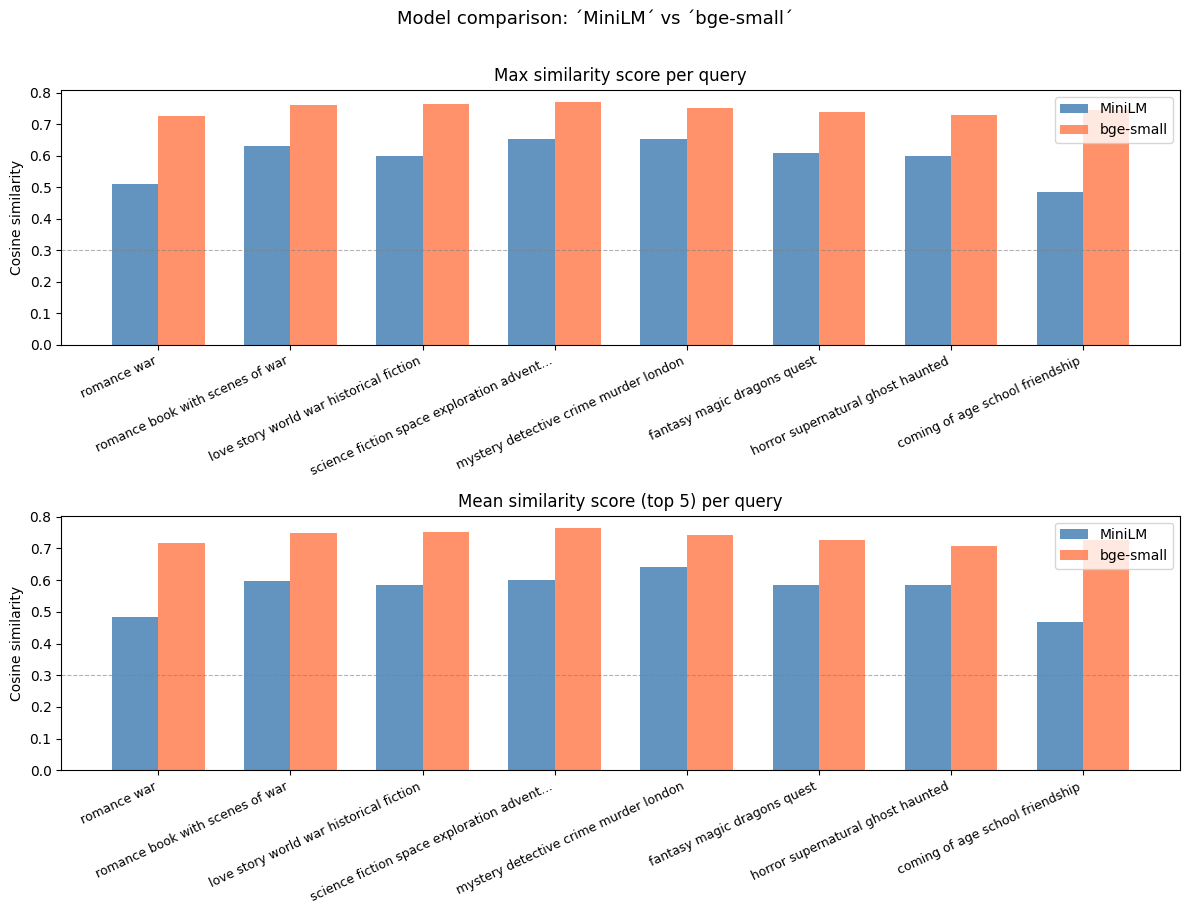

In [31]:
# Bar chart: max score per query, side by side
labels_list = list(models.keys())
queries_short = [q[:40] + ('...' if len(q) > 40 else '') for q in QUERIES]
x = np.arange(len(QUERIES))
width = 0.35
colors = ['steelblue', 'coral']

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

for ax, metric, title in zip(axes, ['max_score', 'mean_score'], ['Max similarity score', 'Mean similarity score (top 5)']):
    for i, label in enumerate(labels_list):
        scores = [results[label][q]['score'].agg('max' if metric == 'max_score' else 'mean') for q in QUERIES]
        ax.bar(x + (i - 0.5) * width, scores, width, label=label, color=colors[i], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(queries_short, rotation=25, ha='right', fontsize=9)
    ax.set_ylabel('Cosine similarity')
    ax.set_title(f'{title} per query')
    ax.legend()
    ax.axhline(0.3, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

plt.suptitle('Model comparison: ´MiniLM´ vs ´bge-small´', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

#### Qualitative comparison — top results

In [32]:
FOCUS_QUERIES = [
    'romance war',
    'fantasy magic dragons quest',
    'mystery detective crime murder london',
]

for q in FOCUS_QUERIES:
    print(f"\n{'═'*70}")
    print(f"Query: '{q}'")
    for label in labels_list:
        res = results[label][q]
        print(f"\n  [{label}]  max={res['score'].max():.3f}  mean={res['score'].mean():.3f}")
        display(res[['title', 'genres', 'score']].to_string(index=False))


══════════════════════════════════════════════════════════════════════
Query: 'romance war'

  [MiniLM]  max=0.509  mean=0.482


'               title                                                      genres  score\n         Angel Light Speculative fiction, Fantasy, Fiction, Romance novel, Novel  0.509\n     Les Guérillères                                                       Novel  0.487\n    Le Corps Lesbien                                                       Novel  0.477\n          Valentines                                                              0.475\nThe Eternal Conflict                                                     Fantasy  0.464'


  [bge-small]  max=0.724  mean=0.717


'               title                                      genres  score\n      This Above All Chivalric romance, War novel, Romance novel  0.724\n      The Charioteer                                              0.719\nZabibah and the King                               Romance novel  0.717\n       War and Peace  War novel, Romance novel, Historical novel  0.717\n     Waking the Dead                               Romance novel  0.706'


══════════════════════════════════════════════════════════════════════
Query: 'fantasy magic dragons quest'

  [MiniLM]  max=0.608  mean=0.584


...

"                   title                                genres  score\n      Dragons of Despair            Role-playing game, Fantasy  0.738\nThe Two Pearls of Wisdom                               Fantasy  0.733\n   The Last Dragonslayer                               Fantasy  0.727\n             Dragoncharm Speculative fiction, Fantasy, Fiction  0.721\n         Queen's Harvest                                        0.718"


══════════════════════════════════════════════════════════════════════
Query: 'mystery detective crime murder london'

  [MiniLM]  max=0.653  mean=0.642


"                   title                                                          genres  score\n          The Hollow Man Mystery, Detective fiction, Locked room mystery, Fiction, Novel  0.653\n  The Incendiary's Trail                                                                  0.649\nThe House on Lily Street                                                                  0.640\n       Cold is the Grave                                          Crime Fiction, Mystery  0.635\n          Strange Affair                                          Crime Fiction, Mystery  0.633"


  [bge-small]  max=0.751  mean=0.741


"                                title                                                          genres  score\n                       The Hollow Man Mystery, Detective fiction, Locked room mystery, Fiction, Novel  0.751\nAgatha Raisin and the Quiche of Death                                      Mystery, Detective fiction  0.742\n                King Solomon's Carpet                                          Crime Fiction, Mystery  0.739\n         The Poisoned Chocolates Case                                      Mystery, Detective fiction  0.737\n                   Death at La Fenice                                          Crime Fiction, Mystery  0.737"

#### Semantic gap test

Queries that require semantic understanding beyond literal word matching.
E.g. *"wizards"* should retrieve books about *"magic"*.

In [34]:
SEMANTIC_QUERIES = [
    ('wizards', 'fantasy magic'),
    ('space travel', 'science fiction'),
    ('forbidden love', 'romance'),
    ('dystopia totalitarian', 'political fiction'),
]

rows = []
for q_literal, _ in SEMANTIC_QUERIES:
    for label in labels_list:
        res = recommend_embeddings(q_literal, 1, df, embedders[label], book_vectors[label])
        rows.append({'Query': q_literal, 'Model': label, 'Max': res['score'].iloc[0], 'Top result': res['title'].iloc[0]})

display(pd.DataFrame(rows))

,Query,Model,Max,Top result
0,wizards,MiniLM,0.466,In the Empire of Shadow
1,wizards,bge-small,0.648,Whizzard!
2,space travel,MiniLM,0.606,Dreadful Sanctuary
3,space travel,bge-small,0.708,The Depths of Time
4,forbidden love,MiniLM,0.543,Forbidden
5,forbidden love,bge-small,0.685,Forbidden
6,dystopia totalitarian,MiniLM,0.554,Kazohinia
7,dystopia totalitarian,bge-small,0.760,The Iron Heel


#### Score distribution

How spreaded are the scores across all books for a given query?
A model with sharper separation (high scores at top, low elsewhere) is more discriminative.

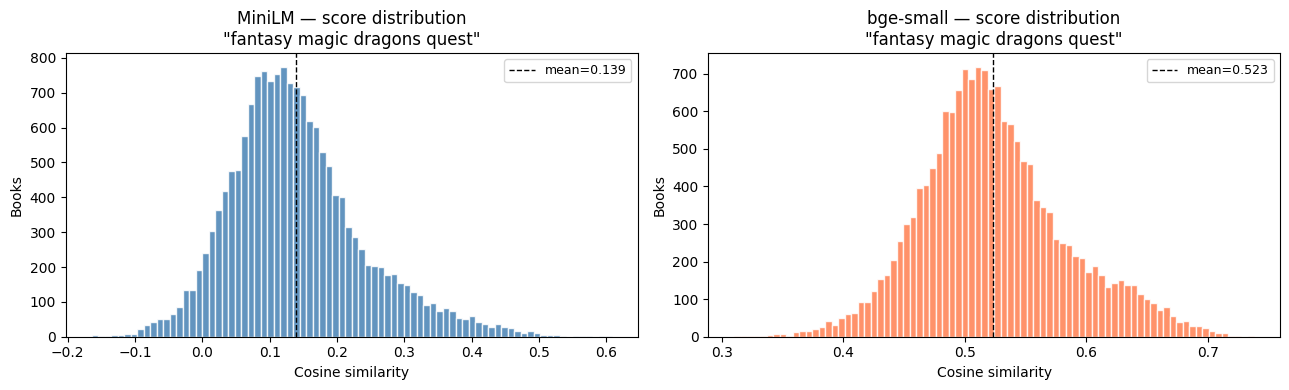

In [35]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

DIST_QUERY = 'fantasy magic dragons quest'

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, label in zip(axes, labels_list):
    query_vec = embedders[label].encode_query(DIST_QUERY)
    all_scores = cos_sim(query_vec, book_vectors[label]).flatten()
    ax.hist(all_scores, bins=80, color='steelblue' if label == 'MiniLM' else 'coral', edgecolor='white', alpha=0.85)
    ax.set_xlabel('Cosine similarity')
    ax.set_ylabel('Books')
    ax.set_title(f'{label} — score distribution\n"{DIST_QUERY}"')
    ax.axvline(all_scores.mean(), color='black', linestyle='--', linewidth=1, label=f'mean={all_scores.mean():.3f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()